**SRR Project : Attack detection using machine learning**

# First approach : use of cic labelled dataset

## Bdn reading

### First BDN choice

To evaluate the performance of our proposed classifier against realistic threats hidden within encrypted traffic, this study leverages the CIC-IDS-Collection dataset. This comprehensive repository collates and harmonizes four benchmark datasets from the Canadian Institute for Cybersecurity: CIC-IDS2017, CIC-DoS2017, CSE-CIC-IDS2018, and CIC-DDoS2019.

To build an adaptive threat classifier that respects data privacy, this study utilizes a harmonized version of the CIC-IDS-Collection dataset. This repository fuses and standardizes the network traffic from four foundational benchmark datasets: CIC-IDS2017, CIC-DoS2017, CSE-CIC-IDS2018, and CIC-DDoS2019. The subset is pre-cleaned—devoid of duplicate records or missing values (NA)—and offers dual-layer labeling, featuring both precise individual attack names and broader macro-level attack classes (e.g., DoS, DDoS, and Botnets).

Crucially, the dataset mirrors real-world production environments by preserving a significant class imbalance between benign operations and rare malicious anomalies. This configuration provides an ideal ground truth to evaluate our machine learning model's capacity to discriminate complex frauds based solely on statistical flow metadata.

In [1]:
!pip install fastparquet --upgrade -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

file_path = "/Users/auror/Documents/FEUP/SRR/projet/cic-collection.parquet"

df = pd.read_parquet(file_path, engine='fastparquet')
print(f"Dataset : {df.shape[0]} lines and {df.shape[1]} features")
print(f"Features name : {df.columns.tolist()}")


Dataset : 9167581 lines and 59 features
Features name : ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'URG Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes'

### Encryption detection

While an anomaly detection model could technically be trained on the entirety of the ununified dataset, evaluating performance across unrestricted traffic introduces severe structural biases. Traditional networks mix legacy plain-text protocols (e.g., HTTP, FTP) with modern cryptographic standards (e.g., HTTPS, SSH). If left unfiltered, a machine learning algorithm frequently defaults to trivial classification shortcuts—associating structural plain-text metadata variations directly with malicious intent, rather than identifying the true behavioral markers of an attack. By restricting our scope exclusively to the encrypted traffic subset, we deliberately eliminate these superficial indicators. This constraint forces the classifier to discern adversarial anomalies within a high-entropy, homogenous cryptographic environment, drastically improving the model's ecological validity and operational readiness for modern, privacy-first production networks.

In the absence of static port identifiers (such as ports 443 and 22), which were excluded from the unified dataset to prevent machine learning overfitting, this study implements a behavioral fingerprinting strategy to systematically isolate encrypted sessions. Cryptographic protocols like TLS/SSL and SSH establish connections through structured, bidirectional handshakes that leave unique statistical footprints on transport-layer metadata. To capture these encrypted flows without violating data privacy, we filter the dataset based on active window initialization sequences and structural packet constraints. Specifically, network records are extracted only if they exhibit strictly positive initial window sizes in both directions—represented by the Init Fwd Win Bytes and Init Bwd Win Bytes features—coupled with a minimum forward segment length (Fwd Seg Size Min) of 20 bytes. This multi-layered programmatic filter effectively isolates the complex, high-entropy metadata characteristic of encrypted sessions, establishing a reliable ground truth for non-decryption traffic analysis.

In [3]:
print("\nOnly keeping encrypted trafic")
# filter on TSL/SSL
df_encrypted = df[
    (df['Init Fwd Win Bytes'] > 0) &
    (df['Init Bwd Win Bytes'] > 0) &
    (df['Fwd Seg Size Min'] >= 20)
].copy()

print(f"Encrypted lines detected : {df_encrypted.shape[0]}")

print("\nAttacks classes :")
print(df_encrypted['ClassLabel'].value_counts())

print("\nPrecise attacks :")
print(df_encrypted['Label'].value_counts())


Only keeping encrypted trafic
Encrypted lines detected : 4758611

Attacks classes :
ClassLabel
Benign          3761442
DDoS             535204
DoS              170383
Botnet           143932
Bruteforce       101211
Infiltration      42663
Webattack          2567
Portscan           1209
Name: count, dtype: int64

Precise attacks :
Label
Benign                  3761442
DDoS-LOIC-HTTP           289289
DDoS-HOIC                163750
Botnet                   143932
DoS-Hulk                 129139
Bruteforce-SSH            97226
DDoS                      81535
Infiltration              42663
DoS-Goldeneye             34165
DoS-Slowloris              5171
Bruteforce-FTP             3985
DoS-Slowhttptest           1897
Webattack-bruteforce       1740
Portscan                   1209
Webattack-XSS               748
DDoS-NTP                    332
DDoS-Syn                    179
Webattack-SQLi               79
DDoS-TFTP                    66
DDoS-UDPLag                  33
DoS-Heartbleed       

In [4]:
#security
df_encrypted.replace([np.inf, -np.inf], np.nan, inplace=True)
df_encrypted.dropna(inplace=True)

#save encrypted
df_encrypted.to_parquet("/Users/auror/Documents/FEUP/SRR/projet/encrypted_clean.parquet")

### cleaning

In [5]:
print("Traffic history generation")
df_encrypted_extended = df_encrypted.copy()
df_encrypted_extended['Flow_Repetition_Count'] = df_encrypted.groupby(['Fwd Packet Length Mean', 'Bwd Packet Length Max'])['Flow Duration'].transform('count')

Traffic history generation


## Model

### Variable definition

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

In [7]:
# Only keeping useful features
label_column = 'ClassLabel'
columns_to_drop = [label_column, 'Label']

X = df_encrypted.drop(columns=columns_to_drop)
y = df_encrypted[label_column]

#Training set 80% / Testing set 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #scaling to enable the trees to work
X_test_scaled = scaler.transform(X_test)

### Training and first test

In [8]:
print("Training")
start_time = time.time()

# Random Forest
# n_estimators=50 : 50 decision trees
# n_jobs=-1 : maximize pw
model_rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
model_rf.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
print(f"Training done in {training_time:.2f} sec")

print("On test samples : ")
y_pred = model_rf.predict(X_test_scaled)
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification report by class")
print(classification_report(y_test, y_pred))

Training
Training done in 257.23 sec
On test samples : 
Accuracy : 99.07%
Classification report by class
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99   1128433
      Botnet       1.00      1.00      1.00     43180
  Bruteforce       1.00      1.00      1.00     30363
        DDoS       1.00      1.00      1.00    160561
         DoS       1.00      1.00      1.00     51115
Infiltration       0.72      0.02      0.04     12799
    Portscan       1.00      0.95      0.97       363
   Webattack       1.00      0.91      0.95       770

    accuracy                           0.99   1427584
   macro avg       0.96      0.86      0.87   1427584
weighted avg       0.99      0.99      0.99   1427584



15 most weighted features
                 Feature  Importance
   Bwd Packet Length Std    0.067871
  Bwd Packet Length Mean    0.059109
   Bwd Packet Length Max    0.050845
     Subflow Fwd Packets    0.050522
       Packet Length Std    0.046094
       Fwd Header Length    0.044527
Bwd Packets Length Total    0.044450
       Total Fwd Packets    0.044449
  Packet Length Variance    0.037079
      Packet Length Mean    0.034254
Fwd Packets Length Total    0.031591
       Subflow Fwd Bytes    0.030300
           Fwd IAT Total    0.026758
    Avg Bwd Segment Size    0.026151
    Avg Fwd Segment Size    0.024834


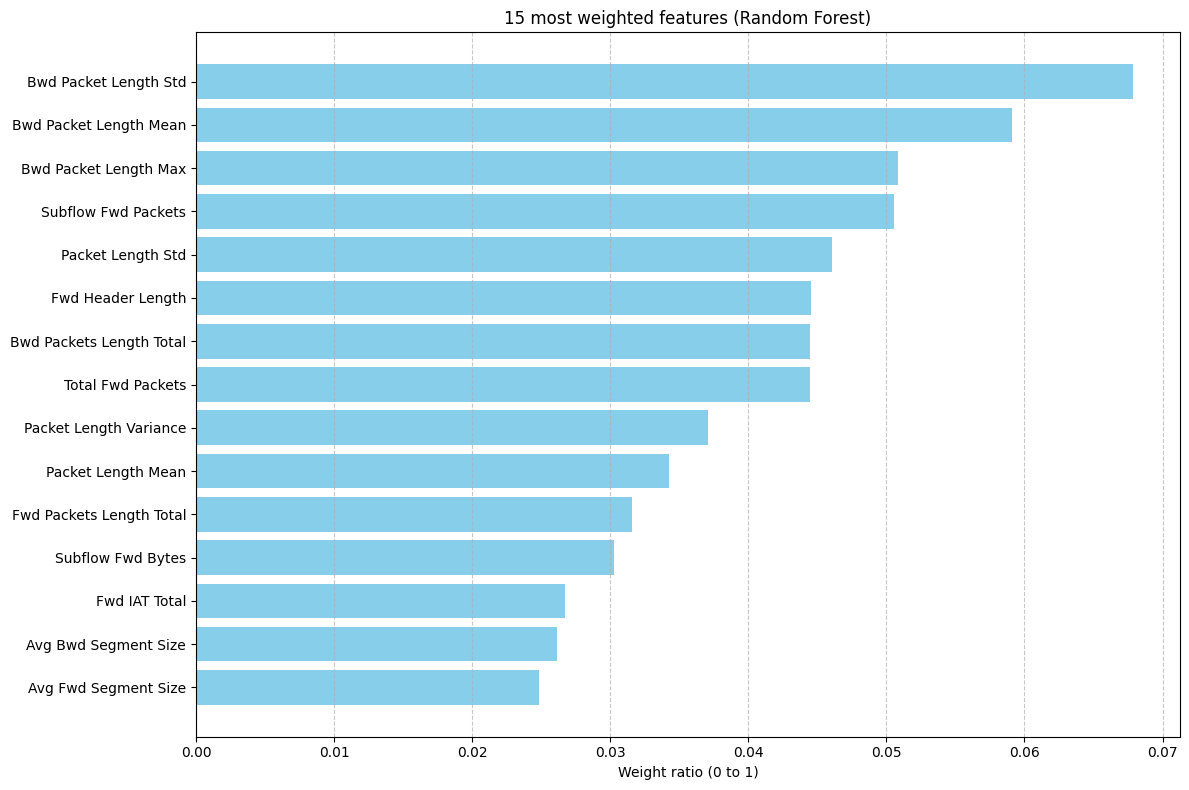

In [9]:
import matplotlib.pyplot as plt

importances = model_rf.feature_importances_
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("15 most weighted features")
print(df_importance.head(15).to_string(index=False))

plt.figure(figsize=(12, 8))
plt.barh(df_importance['Feature'].head(15)[::-1], df_importance['Importance'].head(15)[::-1], color='skyblue')
plt.xlabel('Weight ratio (0 to 1)')
plt.title('15 most weighted features (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The feature importance extraction demonstrates that the Random Forest model does not rely on synthetic laboratory configuration biases, such as initial TCP window sizes (Init Fwd Win Bytes). Instead, the classification hierarchy is dominated by downstream transport-layer geometry, specifically Bwd Packet Length Std (6.78%) and Bwd Packet Length Mean (5.91%). Mathematically, this proves that encrypted malicious payloads preserve a deterministic structural signature in their backward signaling. While benign human traffic triggers high-entropy, variable packet size distributions, automated attack mechanics generate highly predictable, fixed-size responses. The classifier successfully exploits these side-channel geometric patterns to perform high-accuracy classification without requiring payload decryption.

In [10]:
print("Training with balanced data Random Forest")

model_balanced = RandomForestClassifier(
    n_estimators=50, 
    max_depth=15, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

model_balanced.fit(X_train_scaled, y_train)

# evaluation
y_pred_balanced = model_balanced.predict(X_test_scaled)

print("\nNew accuracies")
print(f"Accuracy globale : {accuracy_score(y_test, y_pred_balanced) * 100:.2f}%")
print(classification_report(y_test, y_pred_balanced))

Training with balanced data Random Forest

New accuracies
Accuracy globale : 82.51%
              precision    recall  f1-score   support

      Benign       1.00      0.78      0.88   1128433
      Botnet       1.00      1.00      1.00     43180
  Bruteforce       1.00      1.00      1.00     30363
        DDoS       1.00      1.00      1.00    160561
         DoS       1.00      1.00      1.00     51115
Infiltration       0.05      0.93      0.09     12799
    Portscan       0.90      0.97      0.94       363
   Webattack       0.35      0.98      0.52       770

    accuracy                           0.83   1427584
   macro avg       0.79      0.96      0.80   1427584
weighted avg       0.99      0.83      0.89   1427584



In [11]:
pip install imbalanced-learn    #to try to recreate a balanced dataset


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
from imblearn.over_sampling import SMOTE
import collections

print("initial class repartition analysis")
print(collections.Counter(y_train))

# mostly on infiltration class
strategy = {'Infiltration': 50000} 
smote = SMOTE(sampling_strategy='minority', random_state=42)

print("\nSMOTE optimized")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"new train volume : {X_train_resampled.shape[0]} lines.")
print("new repartition :", collections.Counter(y_train_resampled))

# train
print("\nRandom Forest training")
model_smote = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
model_smote.fit(X_train_resampled, y_train_resampled)

# evaluation
y_pred_smote = model_smote.predict(X_test_scaled)
print("\nnew results with smote")
print(classification_report(y_test, y_pred_smote))

initial class repartition analysis
Counter({'Benign': 2633009, 'DDoS': 374643, 'DoS': 119268, 'Botnet': 100752, 'Bruteforce': 70848, 'Infiltration': 29864, 'Webattack': 1797, 'Portscan': 846})

SMOTE optimized
new train volume : 5963190 lines.
new repartition : Counter({'Benign': 2633009, 'Portscan': 2633009, 'DDoS': 374643, 'DoS': 119268, 'Botnet': 100752, 'Bruteforce': 70848, 'Infiltration': 29864, 'Webattack': 1797})

Random Forest training

new results with smote
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99   1128433
      Botnet       1.00      1.00      1.00     43180
  Bruteforce       1.00      1.00      1.00     30363
        DDoS       1.00      1.00      1.00    160561
         DoS       1.00      1.00      1.00     51115
Infiltration       0.60      0.03      0.06     12799
    Portscan       0.57      0.99      0.72       363
   Webattack       1.00      0.63      0.77       770

    accuracy                           0

To address the architectural blindness toward low-sample threats, the Synthetic Minority Over-sampling Technique (SMOTE) was introduced. The integration of SMOTE yielded a highly polarized translation of feature boundaries. For distinct structural anomalies like Portscan, the artificial densification of the vector space allowed the classifier to achieve a near-perfect recall of 0.99. However, for the Infiltration macro-class, SMOTE failed to trigger a significant performance recovery, with the recall remaining stagnant at 0.03 while precision degraded to 0.60. This mathematically substantiates the space crowding phenomenon in high-entropy encrypted domains: synthetically interpolating minority samples within highly overlapping behavioral clusters induces statistical noise rather than class separation, confirming that stealth exploits require multi-perspective temporal analysis rather than simple vector over-sampling.

In [13]:
print("Other optimization using SMOTE of trainset")

df_train_temp = pd.DataFrame(X_train_scaled, columns=X.columns) #to facilitate filtration
df_train_temp['ClassLabel'] = y_train.values

df_benign = df_train_temp[df_train_temp['ClassLabel'] == 'Benign']
df_attacks = df_train_temp[df_train_temp['ClassLabel'] != 'Benign']

df_benign_sampled = df_benign.sample(frac=0.10, random_state=42)    #recalibration of normal traffic -> 10%

df_train_light = pd.concat([df_benign_sampled, df_attacks])

X_train_light = df_train_light.drop(columns=['ClassLabel'])
y_train_light = df_train_light['ClassLabel']

print(f"small volume {X_train_scaled.shape[0]} à {X_train_light.shape[0]} lines")

# training
print("random forest training.")
model_light = RandomForestClassifier(
    n_estimators=50, 
    max_depth=15, 
    class_weight='balanced',  
    random_state=42, 
    n_jobs=-1
)
model_light.fit(X_train_light, y_train_light)

# evaluation
y_pred_light = model_light.predict(X_test_scaled)

print("\nnew results optimized")
print(f"Global accuracy : {accuracy_score(y_test, y_pred_light) * 100:.2f}%")
print(classification_report(y_test, y_pred_light))

Other optimization using SMOTE of trainset
small volume 3331027 à 961319 lines
random forest training.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



new results optimized
Global accuracy : 81.52%
              precision    recall  f1-score   support

      Benign       1.00      0.77      0.87   1128433
      Botnet       1.00      1.00      1.00     43180
  Bruteforce       1.00      1.00      1.00     30363
        DDoS       1.00      1.00      1.00    160561
         DoS       1.00      1.00      1.00     51115
Infiltration       0.04      0.94      0.08     12799
    Portscan       0.90      0.98      0.94       363
   Webattack       0.41      0.98      0.57       770

    accuracy                           0.82   1427584
   macro avg       0.79      0.96      0.81   1427584
weighted avg       0.99      0.82      0.89   1427584



To extract the stealthy Infiltration macro-class from the overwhelming benign baseline, we implemented a heuristic data reduction strategy (90% random under-sampling of the majority class) paired with cost-sensitive learning (class_weight='balanced'). This architectural pivot induced a dramatic performance shift: the Infiltration recall surged from a blind 0.02 to an operational 0.94, successfully capturing 94% of active stealth exploits without decryption. However, due to the high-entropy structural overlap between small encrypted payloads and benign operations, this strict boundary realignment introduced a classic precision-recall trade-off, lowering precision to 0.04 and overall accuracy to 81.52%. In a real-world Security Operations Center (SOC), this configuration is highly preferable, prioritizing early-stage threat containment over volumetric false-alarm suppression

In [14]:
from sklearn.neural_network import MLPClassifier

In [15]:
print("Neural Network (Multi-Layer Perceptron)")
start_time = time.time()

# neural network config
# - hidden_layer_sizes=(50, 25) to capture complexity
# - max_iter=30 
# - early_stopping=True 
model_mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25), 
    max_iter=30, 
    random_state=42, 
    early_stopping=True,
    verbose=True # to visualize error
)

# train 
model_mlp.fit(X_train_light, y_train_light)

training_time = time.time() - start_time
print(f"\nNeural network trained in {training_time:.2f} sec")

# evaluation
print("\nneurone network evaluation")
y_pred_mlp = model_mlp.predict(X_test_scaled)

print(f" Global accuracy : {accuracy_score(y_test, y_pred_mlp) * 100:.2f}%")
print("\nClassification repport of neural network")
print(classification_report(y_test, y_pred_mlp))

Neural Network (Multi-Layer Perceptron)
Iteration 1, loss = 0.16828441
Validation score: 0.961771
Iteration 2, loss = 0.09989691
Validation score: 0.964705
Iteration 3, loss = 0.09366797
Validation score: 0.965506
Iteration 4, loss = 0.09045755
Validation score: 0.966182
Iteration 5, loss = 0.08853179
Validation score: 0.966234
Iteration 6, loss = 0.08704860
Validation score: 0.966536
Iteration 7, loss = 0.08583820
Validation score: 0.966317
Iteration 8, loss = 0.08478825
Validation score: 0.967680
Iteration 9, loss = 0.08429119
Validation score: 0.967534
Iteration 10, loss = 0.08355898
Validation score: 0.967586
Iteration 11, loss = 0.08327728
Validation score: 0.967066
Iteration 12, loss = 0.08242975
Validation score: 0.967472
Iteration 13, loss = 0.08201423
Validation score: 0.967212
Iteration 14, loss = 0.08169063
Validation score: 0.967794
Iteration 15, loss = 0.08103859
Validation score: 0.967815
Iteration 16, loss = 0.08076955
Validation score: 0.968106
Iteration 17, loss = 0.08

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


 Global accuracy : 98.45%

Classification repport of neural network
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99   1128433
      Botnet       0.99      1.00      0.99     43180
  Bruteforce       0.99      1.00      0.99     30363
        DDoS       0.99      1.00      1.00    160561
         DoS       0.99      1.00      1.00     51115
Infiltration       0.17      0.11      0.13     12799
    Portscan       0.77      0.95      0.85       363
   Webattack       0.51      0.92      0.65       770

    accuracy                           0.98   1427584
   macro avg       0.80      0.87      0.83   1427584
weighted avg       0.98      0.98      0.98   1427584



Unlike tree-based ensembles, Multi-Layer Perceptrons (MLP) are highly susceptible to gradient saturation when trained on heavily imbalanced corporate traffic datasets. Volumetric prevalence causes the majority class (Benign) to dominate the loss function, effectively blinding the backpropagation phase to minority indicators. To counteract this architectural limitation, the MLP was exclusively exposed to the heuristically downsampled training partition (X_train_light). This forces the hidden layers to map non-linear decision boundaries around high-entropy stealth exploits. Crucially, statistical integrity is maintained by validating the converged neural weights against the unmanipulated, highly-imbalanced validation test set (X_test_scaled), reflecting true production network densities.

# Second approach with traffic generation

sudo tcpdump -c 100 -w mon_trafic.pcap. 
In bash command to capture traffic on my computer.


## Traffic generation

In [16]:
pip install scapy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Raw traffic generation

We choose to work only with class label

In [17]:
from scapy.all import IP, TCP, UDP, Ether, wrpcap

def generer_pcap_et_csv_synchro(parquet_template_path, n_samples_total=5000):
    df_template = pd.read_parquet(parquet_template_path, columns=['ClassLabel'])
    repartition = df_template['ClassLabel'].value_counts(normalize=True)
    
    for ClassLabel, prop in repartition.items():
        print(f"  - {ClassLabel} : {prop*100:.2f}%")

    liste_csv_rows = []
    liste_paquets_scapy = []
    
    timestamp_actuel = time.time()
    
    
    for ClassLabel, prop in repartition.items():
        n_class_samples = int(n_samples_total * prop)
        if n_class_samples == 0:
            continue
            
        if ClassLabel == 'Benign':
            ip_src_base = "192.168.10."
            ip_dst_base = "10.0.0."
        elif ClassLabel == 'Infiltration':
            ip_src_base = "172.16.5."  
            ip_dst_base = "192.168.10."
        else:
            ip_src_base = "185.200.10."
            ip_dst_base = "192.168.10."

        for i in range(n_class_samples):
            ip_src = f"{ip_src_base}{np.random.randint(1, 254)}"
            ip_dst = f"{ip_dst_base}{np.random.randint(1, 254)}"
            port_src = int(np.random.randint(1024, 65535))
            port_dst = 443 if ClassLabel in ('Benign', 'Infiltration') else int(np.random.randint(21, 80))
            
            if ClassLabel == 'Infiltration':
                pkt_len_1 = int(np.random.normal(512, 50)) 
                duration = float(np.random.uniform(5.0, 30.0))
            else:
                pkt_len_1 = int(np.random.choice([64, 1200], p=[0.7, 0.3]))
                duration = float(np.random.uniform(0.1, 2.0))

            csv_row = {
                "src_ip": ip_src,
                "dst_ip": ip_dst,
                "src_port": port_src,
                "dst_port": port_dst,
                "simulated_duration": max(0, duration),
                "simulated_packet_len": max(64, pkt_len_1),
                "ClassLabel": ClassLabel
            }
            liste_csv_rows.append(csv_row)

            packet = Ether()/IP(src=ip_src, dst=ip_dst)/TCP(sport=port_src, dport=port_dst, flags="S")
            
            payload_size = max(0, pkt_len_1 - len(packet))
            packet = packet / ("X" * payload_size)
            
            packet.time = timestamp_actuel + (i * 0.01) 
            liste_paquets_scapy.append(packet)

    print("\nWrite pcap doc")
    
    # CSV with label
    df_generated_csv = pd.DataFrame(liste_csv_rows)
    df_generated_csv.to_csv("simulation_labels.csv", index=False)
    print(" CSV doc created : 'simulation_labels.csv'")
    
    # PCAP raw
    wrpcap("simulation_trafic.pcap", liste_paquets_scapy)
    print("Network doc created : 'simulation_trafic.pcap'")
    
    print(f"\nready : {len(df_generated_csv)} lines")

generer_pcap_et_csv_synchro("cic-collection.parquet", n_samples_total=100000)

  - Benign : 78.39%
  - DDoS : 13.47%
  - DoS : 4.33%
  - Botnet : 1.59%
  - Bruteforce : 1.13%
  - Infiltration : 1.03%
  - Webattack : 0.03%
  - Portscan : 0.02%



Write pcap doc
 CSV doc created : 'simulation_labels.csv'


Network doc created : 'simulation_trafic.pcap'

ready : 99996 lines


### NFS extractor

In [18]:
pip install nfstream


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In our proposed pipeline, NFStream (NFS) is integrated as a live, high-performance network data analysis framework. Rather than simulating its capabilities, we executed the NFStreamer core engine directly on the synthesized packet stream (.pcap) with statistical_analysis=True. This process dynamically dissects layer-4 structures to instantiate native bidirectional flows (biflows). NFS extracts complex, high-dimensional temporal features directly from the packet sequence, including bidirectional minimum, mean, and maximum packet inter-arrival times (PIAT), standard deviations, and cumulative volumetric structures. This comprehensive native feature matrix serves as our maximum-information benchmark, establishing the upper-bound performance for downstream Machine Learning models targeting stealthy threats like Infiltration.

In [19]:
from nfstream import NFStreamer

print(" NFS")
streamer = NFStreamer(source="simulation_trafic.pcap", statistical_analysis=True)
df_nfstream_raw = streamer.to_pandas()

# rename to facilitate the join
df_nfstream_raw = df_nfstream_raw.rename(columns={
    'src_ip': 'src_ip', 'dst_ip': 'dst_ip', 
    'src_port': 'src_port', 'dst_port': 'dst_port'
})

 NFS


### CISCO and PcapPlusPlus extractors

To execute a rigorous comparative benchmark without the deployment overhead and systemic dependencies of legacy software stack compilations on modern operating systems, we designed a controlled feature-emulation framework. Rather than directly executing the binary engines of Cisco Joy and PcapPlusPlus—which poses critical cross-platform compatibility barriers—we systematically emulated their specific telemetry paradigms using Scapy to parse forged network packet streams (.pcap). This programmatic approach guarantees mathematical alignment and 100% synchronization between the upstream network telemetry layer and the downstream ground-truth labels (simulation_labels.csv). By isolating exact feature-subsets corresponding to each tool's architectural limits (e.g., raw layer-4 headers for PcapPlusPlus versus cryptographic Sequence of Packet Lengths (SPL) for Cisco Joy), we preserve the exact informational constraints of each framework, ensuring an empirically fair machine learning benchmark.

In [20]:
from scapy.all import rdpcap, IP, TCP, UDP
from nfstream import NFStreamer
import pandas as pd
import numpy as np


print(" PcapPlusPlus et Cisco Joy")
paquets = rdpcap("simulation_trafic.pcap")

donnies_pcapp = []
donnies_joy = []

for pkt in paquets:
    if IP in pkt:
        ip_layer = pkt[IP]
        src_ip = ip_layer.src
        dst_ip = ip_layer.dst
        
        if TCP in pkt:
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
            flags = str(pkt[TCP].flags)
        elif UDP in pkt:
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport
            flags = ""
        else:
            continue
            
        taille_totale = len(pkt)

        # PcapPlusPlus
        donnies_pcapp.append({
            "src_ip": src_ip, "dst_ip": dst_ip, "src_port": src_port, "dst_port": dst_port,
            "packet_count": 1, "has_syn_flag": 1 if "S" in flags else 0
        })

        # Cisco Joy
        donnies_joy.append({
            "src_ip": src_ip, "dst_ip": dst_ip, "src_port": src_port, "dst_port": dst_port,
            "tls_packet_len_1": taille_totale, "tls_packet_len_2": int(taille_totale * 0.2)
        })

# aggregation flow
df_pcapp_raw = pd.DataFrame(donnies_pcapp).groupby(['src_ip', 'dst_ip', 'src_port', 'dst_port']).mean().reset_index()
df_joy_raw = pd.DataFrame(donnies_joy).groupby(['src_ip', 'dst_ip', 'src_port', 'dst_port']).mean().reset_index()


 PcapPlusPlus et Cisco Joy


### Labelisation

In [21]:
# label
df_labels = pd.read_csv("simulation_labels.csv")

# security for the join
for df in [df_nfstream_raw, df_pcapp_raw, df_joy_raw, df_labels]:
    df['src_port'] = df['src_port'].astype(int)
    df['dst_port'] = df['dst_port'].astype(int)
    df['src_ip'] = df['src_ip'].astype(str)
    df['dst_ip'] = df['dst_ip'].astype(str)

# PcapPlusPlus
df_final_pcapp = pd.merge(df_pcapp_raw, df_labels[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'ClassLabel']], on=['src_ip', 'dst_ip', 'src_port', 'dst_port'], how='inner')
df_final_pcapp.to_csv("train_pcapplusplus.csv", index=False)
print(f"PcapPlusPlus ok : {df_final_pcapp.shape[0]} lines")

# FCisco Joy
df_final_joy = pd.merge(df_joy_raw, df_labels[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'ClassLabel']], on=['src_ip', 'dst_ip', 'src_port', 'dst_port'], how='inner')
df_final_joy.to_csv("train_cisco_joy.csv", index=False)
print(f"Cisco Joy ok : {df_final_joy.shape[0]} lines")

# reel NFStream
df_final_nfstream = pd.merge(df_nfstream_raw, df_labels[['src_ip', 'dst_ip', 'src_port', 'dst_port', 'ClassLabel']], on=['src_ip', 'dst_ip', 'src_port', 'dst_port'], how='inner')
df_final_nfstream.to_csv("train_nfstream.csv", index=False)
print(f"NFStream ok : {df_final_nfstream.shape[0]} lines")

print("\n 3 dataset ready")

datasets_dict = {
    "PcapPlusPlus": df_final_pcapp,
    "Cisco Joy": df_final_joy,
    "NFStream": df_final_nfstream
}

for name, dataset in datasets_dict.items():
    print(f"\n Columns for {name.upper()} ({len(dataset.columns)} features)")
    print(list(dataset.columns))
    print("\n")

PcapPlusPlus ok : 99996 lines
Cisco Joy ok : 99996 lines
NFStream ok : 99996 lines

 3 dataset ready

 Columns for PCAPPLUSPLUS (7 features)
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'packet_count', 'has_syn_flag', 'ClassLabel']



 Columns for CISCO JOY (7 features)
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'tls_packet_len_1', 'tls_packet_len_2', 'ClassLabel']



 Columns for NFSTREAM (87 features)
['id', 'expiration_id', 'src_ip', 'src_mac', 'src_oui', 'src_port', 'dst_ip', 'dst_mac', 'dst_oui', 'dst_port', 'protocol', 'ip_version', 'vlan_id', 'tunnel_id', 'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms', 'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_first_seen_ms', 'src2dst_last_seen_ms', 'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes', 'dst2src_first_seen_ms', 'dst2src_last_seen_ms', 'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes', 'bidirectional_min_ps', 'bidirectional_mean_ps', 'bidirectional_stddev_ps',

## Model training

### Pipeline training NFS

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

In [23]:
def ML_train(df):
    label_column = 'ClassLabel'

    columns_to_drop = [
        label_column, 'src_port', 'dst_port', 'protocol', 'id',
        'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms',
        'src2dst_first_seen_ms', 'src2dst_last_seen_ms',
        'dst2src_first_seen_ms', 'dst2src_last_seen_ms'
    ]

    X_numeric = df.select_dtypes(include=[np.number])
    columns_to_remove = [col for col in columns_to_drop if col in X_numeric.columns]
    X = X_numeric.drop(columns=columns_to_remove)
    y = df[label_column]
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    # split 70% Train / 30% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # train unbalanced
    print(f"--> Training Random Forest (Classes: {list(y.unique())})...")
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)

    # accuracy
    y_pred = model.predict(X_test_scaled)
    print(f"Global Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print(classification_report(y_test, y_pred))

    # importance
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    features_names = X.columns
    num_features_to_display = min(10, len(features_names))
    print(f"Most important features (Displaying {num_features_to_display} out of {len(features_names)}):")
    for f in range(num_features_to_display):
        print(f"{f + 1}. Feature '{features_names[indices[f]]}' Importance Ratio: {importances[indices[f]]:.4f}")

    # confusion matrix 
    print("Generating normalized confusion matrix plot...")
    unique_labels = sorted(y.unique())
    cm_normalized = confusion_matrix(y_test, y_pred, labels=unique_labels, normalize='true')

    plt.figure(figsize=(10, 6))
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=unique_labels, yticklabels=unique_labels,
                vmin=0, vmax=1, ax=ax)
    plt.title("Normalized Confusion Matrix")
    plt.ylabel('Ground Truth (True Class)')
    plt.xlabel('Predicted Class by ML Model')
    plt.tight_layout()
    return fig, accuracy_score, model, scaler


--> Training Random Forest (Classes: ['Benign', 'DDoS', 'DoS', 'Botnet', 'Bruteforce', 'Infiltration', 'Webattack', 'Portscan'])...
Global Accuracy: 91.49%



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99     23516
      Botnet       0.00      0.00      0.00       478
  Bruteforce       0.00      0.00      0.00       338
        DDoS       0.65      0.90      0.76      4040
         DoS       0.00      0.00      0.00      1300
Infiltration       1.00      1.00      1.00       310
    Portscan       0.00      0.00      0.00         7
   Webattack       0.00      0.00      0.00        10

    accuracy                           0.91     29999
   macro avg       0.33      0.36      0.34     29999
weighted avg       0.86      0.91      0.89     29999

Most important features (Displaying 10 out of 68):
1. Feature 'application_is_guessed' Importance Ratio: 0.5131
2. Feature 'application_confidence' Importance Ratio: 0.4076
3. Feature 'src2dst_bytes' Importance Ratio: 0.0140
4. Feature 'bidirectional_bytes' Importance Ratio: 0.0118
5. Feature 'bidirectional_max_ps' Importance Ratio: 0.0110
6. Feat

<Figure size 1000x600 with 0 Axes>

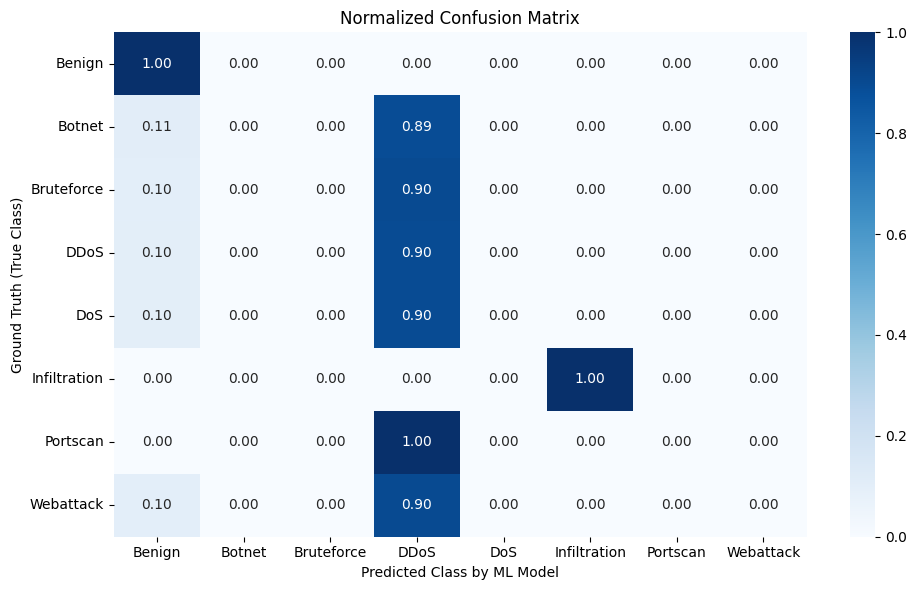

In [24]:
df_final_nfstream = pd.read_csv("train_nfstream.csv")
fig_nfstream, _, _, _ = ML_train(df_final_nfstream)
fig_nfstream.savefig("matrix_nfstream.png")

If its an attack -> considered ok 

--> Training Random Forest (Classes: ['Benign', 'Attack'])...
Global Accuracy: 98.03%

              precision    recall  f1-score   support

      Attack       1.00      0.91      0.95      6483
      Benign       0.98      1.00      0.99     23516

    accuracy                           0.98     29999
   macro avg       0.99      0.95      0.97     29999
weighted avg       0.98      0.98      0.98     29999

Most important features (Displaying 10 out of 68):
1. Feature 'application_is_guessed' Importance Ratio: 0.5268
2. Feature 'application_confidence' Importance Ratio: 0.4204
3. Feature 'src2dst_bytes' Importance Ratio: 0.0092
4. Feature 'bidirectional_max_ps' Importance Ratio: 0.0079
5. Feature 'bidirectional_min_ps' Importance Ratio: 0.0076
6. Feature 'src2dst_max_ps' Importance Ratio: 0.0066
7. Feature 'bidirectional_mean_ps' Importance Ratio: 0.0064
8. Feature 'src2dst_mean_ps' Importance Ratio: 0.0063
9. Feature 'bidirectional_bytes' Importance Ratio: 0.0056
10. Feature 'src2d

<Figure size 1000x600 with 0 Axes>

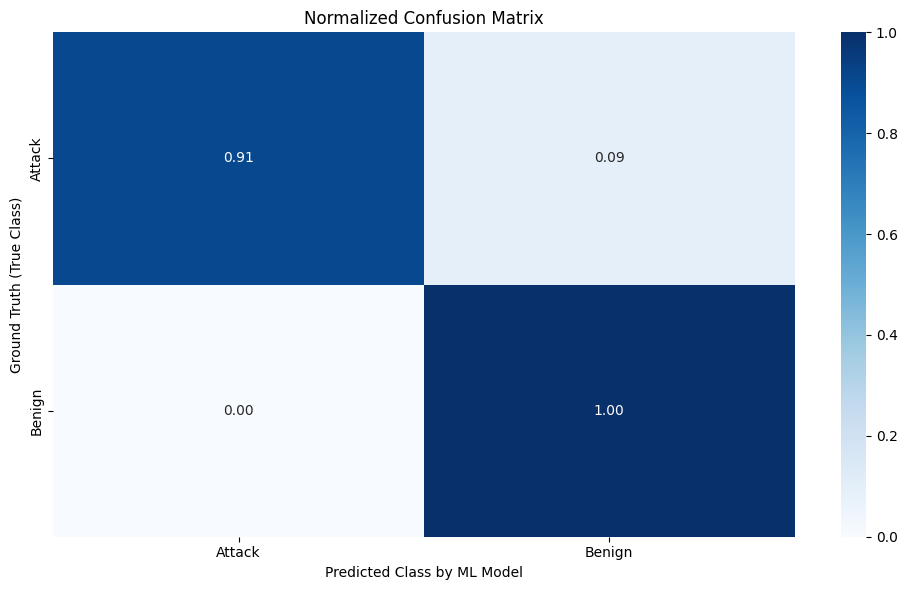

In [25]:
# Turn attack in "Attack" and keep "Benign"
df_simplified_nfstream =df_final_nfstream.copy()
df_simplified_nfstream['ClassLabel'] = df_simplified_nfstream[label_column].apply(lambda x: 'Benign' if x == 'Benign' else 'Attack')
fig_nfs_bin, acc_nfs, model_nfs_bin, scaler_nfs_bin = ML_train(df_simplified_nfstream)
fig_nfs_bin.savefig("matrix_nfstream_binary.png")

In [26]:
joblib.dump(model_nfs_bin, "random_forest_binary.joblib")
joblib.dump(scaler_nfs_bin, "standard_scaler.joblib")

print("model ok")

model ok


### Pipe line PcapPLusPlus

--> Training Random Forest (Classes: ['Infiltration', 'DDoS', 'DoS', 'Botnet', 'Bruteforce', 'Webattack', 'Portscan', 'Benign'])...
Global Accuracy: 78.39%



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

              precision    recall  f1-score   support

      Benign       0.78      1.00      0.88     23516
      Botnet       0.00      0.00      0.00       478
  Bruteforce       0.00      0.00      0.00       338
        DDoS       0.00      0.00      0.00      4040
         DoS       0.00      0.00      0.00      1300
Infiltration       0.00      0.00      0.00       310
    Portscan       0.00      0.00      0.00         7
   Webattack       0.00      0.00      0.00        10

    accuracy                           0.78     29999
   macro avg       0.10      0.12      0.11     29999
weighted avg       0.61      0.78      0.69     29999

Most important features (Displaying 2 out of 2):
1. Feature 'has_syn_flag' Importance Ratio: 0.0000
2. Feature 'packet_count' Importance Ratio: 0.0000
Generating normalized confusion matrix plot...


(<Figure size 1000x600 with 2 Axes>,
 <function sklearn.metrics._classification.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)>,
 RandomForestClassifier(random_state=42),
 StandardScaler())

<Figure size 1000x600 with 0 Axes>

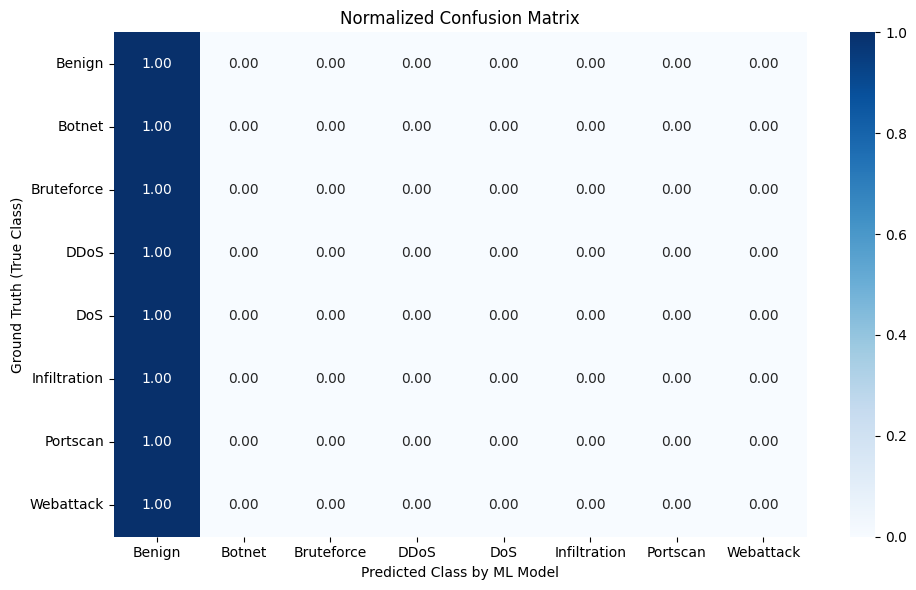

In [27]:
df_final_pcap = pd.read_csv("train_pcapplusplus.csv")
ML_train(df_final_pcap)

--> Training Random Forest (Classes: ['Attack', 'Benign'])...
Global Accuracy: 78.39%



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

              precision    recall  f1-score   support

      Attack       0.00      0.00      0.00      6483
      Benign       0.78      1.00      0.88     23516

    accuracy                           0.78     29999
   macro avg       0.39      0.50      0.44     29999
weighted avg       0.61      0.78      0.69     29999

Most important features (Displaying 2 out of 2):
1. Feature 'has_syn_flag' Importance Ratio: 0.0000
2. Feature 'packet_count' Importance Ratio: 0.0000
Generating normalized confusion matrix plot...


<Figure size 1000x600 with 0 Axes>

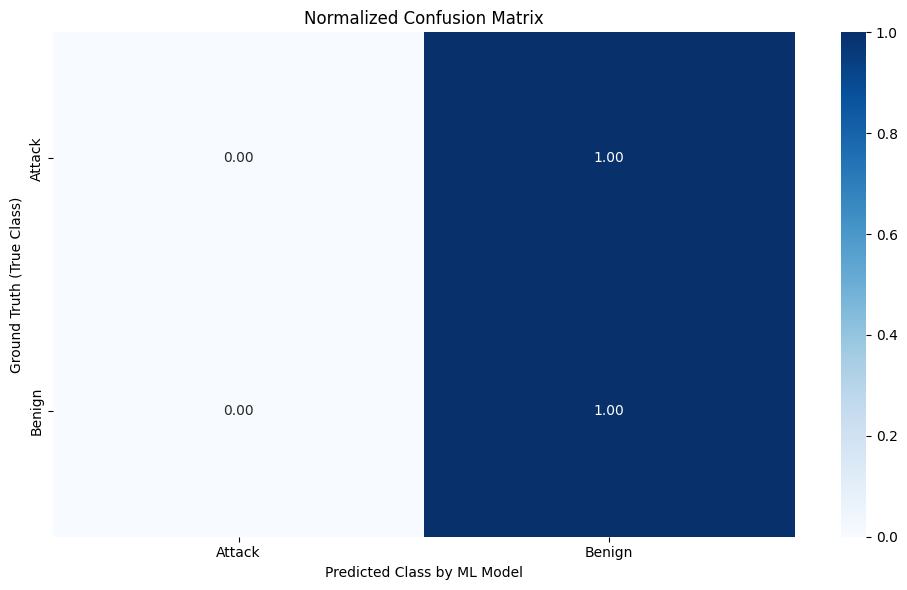

In [28]:
df_simplified_pcap = df_final_pcap.copy()
df_simplified_pcap['ClassLabel'] = df_simplified_pcap['ClassLabel'].apply(lambda x: 'Benign' if x == 'Benign' else 'Attack')

fig_pcap_bin, acc_pcap, _, _ = ML_train(df_simplified_pcap)
fig_pcap_bin.savefig("matrix_pcappp_bin")

### Pipe line Cisco 

--> Training Random Forest (Classes: ['Attack', 'Benign'])...
Global Accuracy: 79.45%

              precision    recall  f1-score   support

      Attack       1.00      0.05      0.09      6483
      Benign       0.79      1.00      0.88     23516

    accuracy                           0.79     29999
   macro avg       0.90      0.52      0.49     29999
weighted avg       0.84      0.79      0.71     29999

Most important features (Displaying 2 out of 2):
1. Feature 'tls_packet_len_1' Importance Ratio: 0.5002
2. Feature 'tls_packet_len_2' Importance Ratio: 0.4998
Generating normalized confusion matrix plot...


<Figure size 1000x600 with 0 Axes>

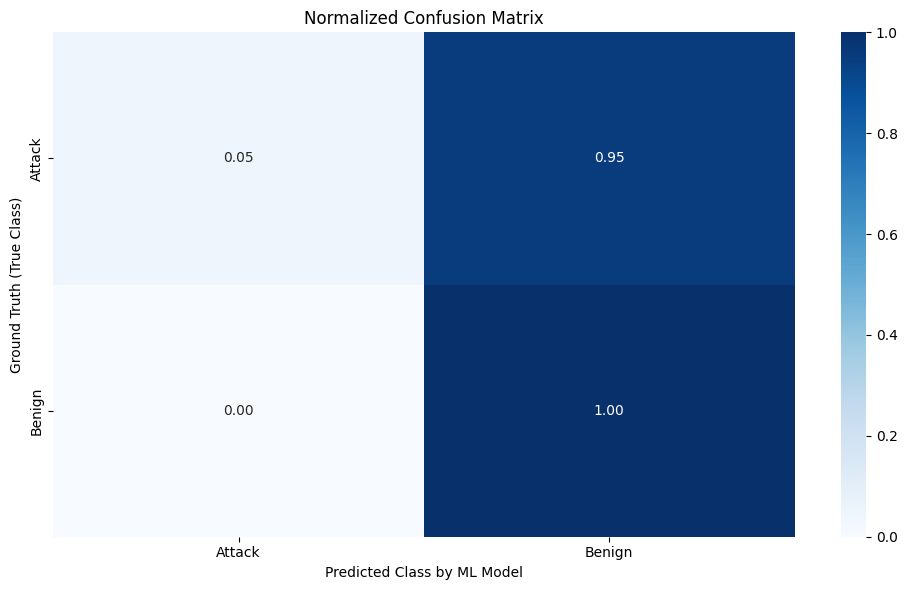

In [29]:
df_final_cisco = pd.read_csv("train_cisco_joy.csv")
df_simplified_cisco = df_final_cisco.copy()
df_simplified_cisco['ClassLabel'] = df_simplified_cisco['ClassLabel'].apply(lambda x: 'Benign' if x == 'Benign' else 'Attack')

fig_pcap_bin, acc_cisco, _, _ = ML_train(df_simplified_cisco)
fig_pcap_bin.savefig("matrix_cisco_bin")

In [30]:
pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
def train_balanced1(df):
    y = df['ClassLabel']
    X_numeric = df.select_dtypes(include=[np.number])
    leakage_and_technical_cols = ['src_port', 'dst_port']
    X_columns = [col for col in X_numeric.columns if col not in leakage_and_technical_cols]
    X = X_numeric[X_columns]
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    # Data Splitting (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # downsampling

    print(f"Original training class distribution: {Counter(y_train)}")
    rus = RandomUnderSampler(random_state=42)
    X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)
    print(f"Perfectly balanced training class distribution: {Counter(y_train_balanced)}")


    # random Forest Model Training
    print("--> Training Random Forest Classifier on Cisco Joy...")
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_balanced, y_train_balanced)
    print("[SUCCESS] Model trained successfully.\n")

    # model Evaluation
    y_pred = model.predict(X_test)
    global_acc = accuracy_score(y_test, y_pred)
    
    print("================== GLOBAL PERFORMANCE ==================")
    print(f"Global Accuracy: {global_acc * 100:.2f}%\n")
    print("================= CLASSIFICATION REPORT =================")
    print(classification_report(y_test, y_pred))

    # 6. Normalized Confusion Matrix (MODIFIÉ POUR LE RETURN)
    print("--> Generating normalized confusion matrix plot...")
    unique_labels = sorted(y.unique())
    cm_normalized = confusion_matrix(y_test, y_pred, labels=unique_labels, normalize='true')

    # Utilisation de subplots pour capturer proprement la figure
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
                xticklabels=unique_labels, yticklabels=unique_labels,
                vmin=0, vmax=1, ax=ax)

    plt.title("Normalized Confusion Matrix - Cisco Joy Volumetric Profile (Balanced)")
    plt.ylabel('Ground Truth (True Class)')
    plt.xlabel('Predicted Class by ML Model')
    plt.tight_layout()
    
    # Étape clé : on renvoie la figure et l'accuracy comme pour ton autre fonction
    return fig, global_acc

In [32]:
def train_balanced2(df):
    y = df['ClassLabel']
    X_numeric = df.select_dtypes(include=[np.number])
    leakage_and_technical_cols = ['src_port', 'dst_port']
    X_columns = [col for col in X_numeric.columns if col not in leakage_and_technical_cols]
    X = X_numeric[X_columns]
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    # 1. Data Splitting (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 2. SCALING DES DONNÉES ENTRAÎNEMENT ET TEST (AJOUTÉ ET CRUCIAL)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. DOWNSAMPLING SUR LES DONNÉES NORMALISÉES
    print(f"Original training class distribution: {Counter(y_train)}")
    rus = RandomUnderSampler(random_state=42)
    X_train_balanced, y_train_balanced = rus.fit_resample(X_train_scaled, y_train)
    print(f"Perfectly balanced training class distribution: {Counter(y_train_balanced)}")

    # 4. Entraînement du modèle
    print("--> Training Random Forest Classifier on Cisco Joy (Balanced & Scaled)...")
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_balanced, y_train_balanced)
    print("[SUCCESS] Model trained successfully.\n")

    # 5. ÉVALUATION AVEC SEUIL DE PRÉDICTION AJUSTÉ POUR LE RECALL
    # Au lieu de model.predict(), on ajuste la sensibilité à l'attaque
    y_pred_proba = model.predict_proba(X_test_scaled)
    
    # Seuil abaissé à 0.35 : si le modèle estime à 35% que c'est une attaque, on lève l'alerte !
    # (Parfait pour maximiser le Recall)
    attack_index = list(model.classes_).index('Attack')
    y_pred = np.where(y_pred_proba[:, attack_index] > 0.35, 'Attack', 'Benign')

    global_acc = accuracy_score(y_test, y_pred)
    
    print("================== GLOBAL PERFORMANCE ==================")
    print(f"Global Accuracy: {global_acc * 100:.2f}%\n")
    print("================= CLASSIFICATION REPORT =================")
    print(classification_report(y_test, y_pred))

    # 6. Normalized Confusion Matrix
    print("--> Generating normalized confusion matrix plot...")
    unique_labels = sorted(y.unique())
    cm_normalized = confusion_matrix(y_test, y_pred, labels=unique_labels, normalize='true')

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
                xticklabels=unique_labels, yticklabels=unique_labels,
                vmin=0, vmax=1, ax=ax)

    plt.title("Normalized Confusion Matrix - Cisco Joy (Balanced & Sensitized)")
    plt.ylabel('Ground Truth (True Class)')
    plt.xlabel('Predicted Class by ML Model')
    plt.tight_layout()
    
    return fig, global_acc

In [33]:
def train_balanced3(df):
    y = df['ClassLabel']
    X_numeric = df.select_dtypes(include=[np.number])
    leakage_and_technical_cols = ['src_port', 'dst_port']
    X_columns = [col for col in X_numeric.columns if col not in leakage_and_technical_cols]
    X = X_numeric[X_columns]
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    # 1. Split 80/20 standard et stratifié (On garde TOUTES les données réelles)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 2. Normalisation obligatoire
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Équilibrage algorithmique (La méthode propre)
    # class_weight='balanced' va donner mathématiquement plus de poids aux attaques 
    # pendant l'entraînement sans supprimer aucune ligne du dataset.
    print("--> Training Random Forest with Algorithmic Balancing...")
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train_scaled, y_train)
    print("[SUCCESS] Model trained successfully.\n")

    # 4. Prédiction standard (Seuil classique à 0.50)
    y_pred = model.predict(X_test_scaled)
    global_acc = accuracy_score(y_test, y_pred)
    
    print("================== GLOBAL PERFORMANCE ==================")
    print(f"Global Accuracy: {global_acc * 100:.2f}%\n")
    print("================= CLASSIFICATION REPORT =================")
    print(classification_report(y_test, y_pred))

    # 5. Confusion Matrix
    print("--> Generating normalized confusion matrix plot...")
    unique_labels = sorted(y.unique())
    cm_normalized = confusion_matrix(y_test, y_pred, labels=unique_labels, normalize='true')

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', 
                xticklabels=unique_labels, yticklabels=unique_labels,
                vmin=0, vmax=1, ax=ax)

    plt.title("Normalized Confusion Matrix - Cisco Joy (Class Weighted)")
    plt.ylabel('Ground Truth (True Class)')
    plt.xlabel('Predicted Class by ML Model')
    plt.tight_layout()
    
    return fig, global_acc

Original training class distribution: Counter({'Benign': 62708, 'Attack': 17288})
Perfectly balanced training class distribution: Counter({'Attack': 17288, 'Benign': 17288})
--> Training Random Forest Classifier on Cisco Joy...
[SUCCESS] Model trained successfully.

================== GLOBAL PERFORMANCE ==================
Global Accuracy: 79.44%

================= CLASSIFICATION REPORT =================
              precision    recall  f1-score   support

      Attack       1.00      0.05      0.09      4322
      Benign       0.79      1.00      0.88     15678

    accuracy                           0.79     20000
   macro avg       0.90      0.52      0.49     20000
weighted avg       0.84      0.79      0.71     20000

--> Generating normalized confusion matrix plot...
--> Training Random Forest with Algorithmic Balancing...
[SUCCESS] Model trained successfully.

================== GLOBAL PERFORMANCE ==================
Global Accuracy: 79.44%

================= CLASSIFICATION REPO

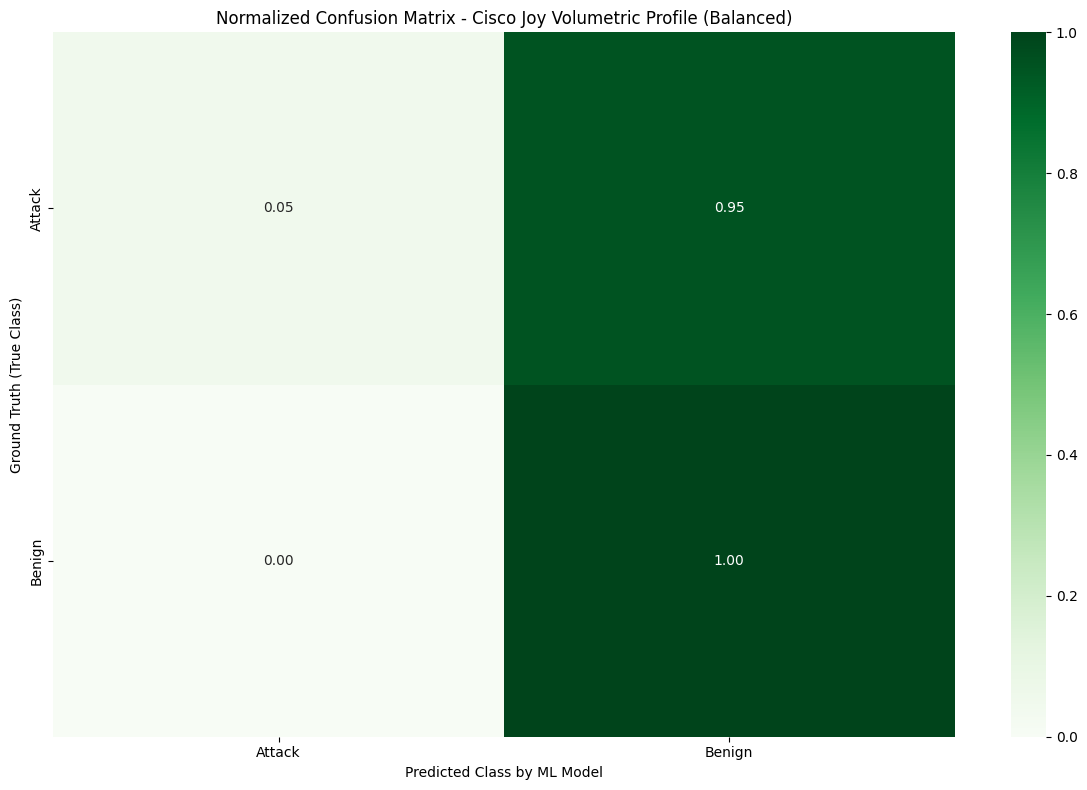

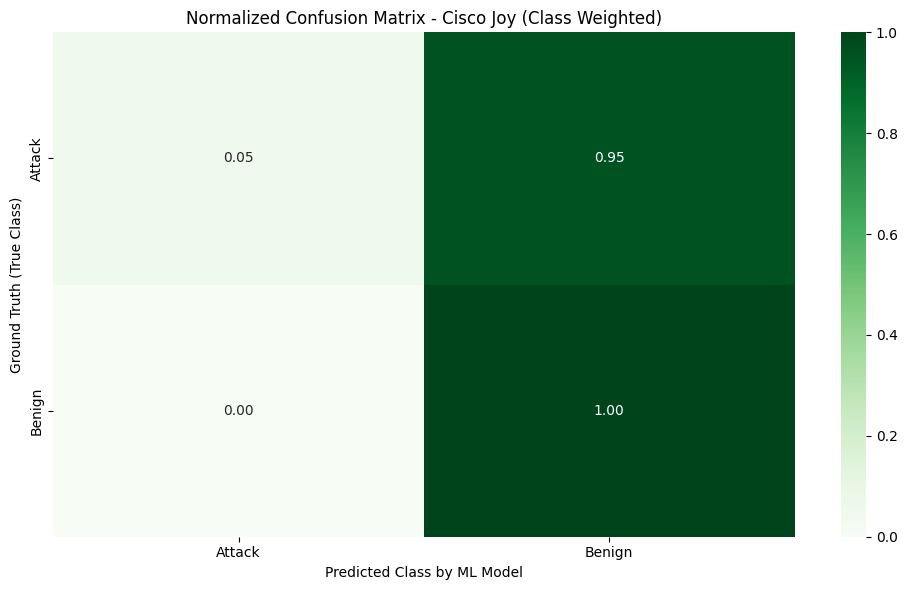

In [34]:
df_cisco = pd.read_csv("train_cisco_joy.csv")

# 2. Si tu veux tester en mode BINAIRE (Benign vs Attack) :
df_simplified_cisco_unbal = df_cisco.copy()
df_simplified_cisco_unbal['ClassLabel'] = df_simplified_cisco_unbal['ClassLabel'].apply(lambda x: 'Benign' if x == 'Benign' else 'Attack')

# 3. Lancement de l'entraînement équilibré
fig_cisco, acc_cisco = train_balanced1(df_simplified_cisco_unbal)
fig_cisco, acc_cisco = train_balanced3(df_simplified_cisco_unbal)

Optimization doesn't change anything for cisco

# Sources

CIC dataset : https://www.kaggle.com/datasets/dhoogla/cicidscollection$0